<a href="https://colab.research.google.com/github/goutham3010/Hospital-Readmission-Prediction-System/blob/main/05_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOSPITAL READMISSION PREDICTION SYSTEM
## NOTEBOOK 05: MODEL EVALUATION
Comprehensive evaluation of trained classification models using Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, and ROC Curve analysis.


### 1. IMPORT LIBRARIES


In [14]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. LOAD DATASET


In [15]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv( "/content/hospital_readmission_dataset.csv")
print("Original dataset shape:", df.shape)
display(df.head())


Original dataset shape: (8000, 17)


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


### 3. DATA CLEANING


In [16]:
# ============================================================
# 3. DATA CLEANING
# ============================================================

# Remove duplicate records
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# Remove unnecessary / potentially leakage-related columns
columns_to_drop = [
    "patient_id",
    "admission_date",
    "readmission_risk_score"
]

# Drop only columns that exist
columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=columns_to_drop)

print("\nRemoved columns:")
print(columns_to_drop)


Shape after removing duplicates: (8000, 17)

Removed columns:
['patient_id', 'admission_date', 'readmission_risk_score']


### 4. SEPARATE FEATURES AND TARGET


In [17]:
# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["label"])
y = df["label"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)



Features shape: (8000, 13)
Target shape: (8000,)


### 5. IDENTIFY FEATURE TYPES


In [18]:
# ============================================================
# 5. IDENTIFY FEATURE TYPES
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)



Numerical Features:
['age', 'comorbidities_count', 'length_of_stay', 'medications_count', 'followup_visits_last_year', 'prev_readmissions']

Categorical Features:
['season', 'gender', 'region', 'primary_diagnosis', 'treatment_type', 'insurance_type', 'discharge_disposition']


### 6. TRAIN / TEST SPLIT


In [19]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))



Training samples: 6400
Testing samples : 1600


### 7. PREPROCESSING PIPELINES


In [20]:
# ============================================================
# 7. PREPROCESSING PIPELINES
# ============================================================

# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline built successfully.")


Preprocessing pipeline built successfully.


### 8. DEFINE MODELS


In [21]:
# ============================================================
# 8. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=6,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
}

print(f"Models initialized: {list(models.keys())}")


Models initialized: ['Logistic Regression', 'Decision Tree', 'Random Forest']


### 9. TRAIN AND EVALUATE EACH MODEL


In [22]:
# ============================================================
# 9. TRAIN AND EVALUATE EACH MODEL
# ============================================================

results = {}

trained_models = {}

for model_name, model in models.items():

    print("\n")
    print("=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability of class 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Store results
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    trained_models[model_name] = pipeline

    # Print results
    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Not Readmitted",
                "Readmitted"
            ],
            zero_division=0
        )
    )




MODEL: Logistic Regression

Accuracy : 0.7444
Precision: 0.9259
Recall   : 0.7276
F1 Score : 0.8148
ROC-AUC  : 0.84

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.46      0.80      0.59       363
    Readmitted       0.93      0.73      0.81      1237

      accuracy                           0.74      1600
     macro avg       0.69      0.76      0.70      1600
  weighted avg       0.82      0.74      0.76      1600



MODEL: Decision Tree

Accuracy : 0.6813
Precision: 0.9173
Recall   : 0.6459
F1 Score : 0.7581
ROC-AUC  : 0.7996

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.40      0.80      0.53       363
    Readmitted       0.92      0.65      0.76      1237

      accuracy                           0.68      1600
     macro avg       0.66      0.72      0.65      1600
  weighted avg       0.80      0.68      0.71      1600



MODEL: Random Forest

Accuracy : 0.7688


### 10. CREATE MODEL COMPARISON TABLE


In [23]:
# ============================================================
# 10. CREATE MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
).T

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.round(4)
)




MODEL COMPARISON


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.7688,0.8959,0.7930,0.8413,0.8285
Logistic Regression,0.7444,0.9259,0.7276,0.8148,0.8400
Decision Tree,0.6812,0.9173,0.6459,0.7581,0.7996


### 11. VISUALIZE MODEL PERFORMANCE


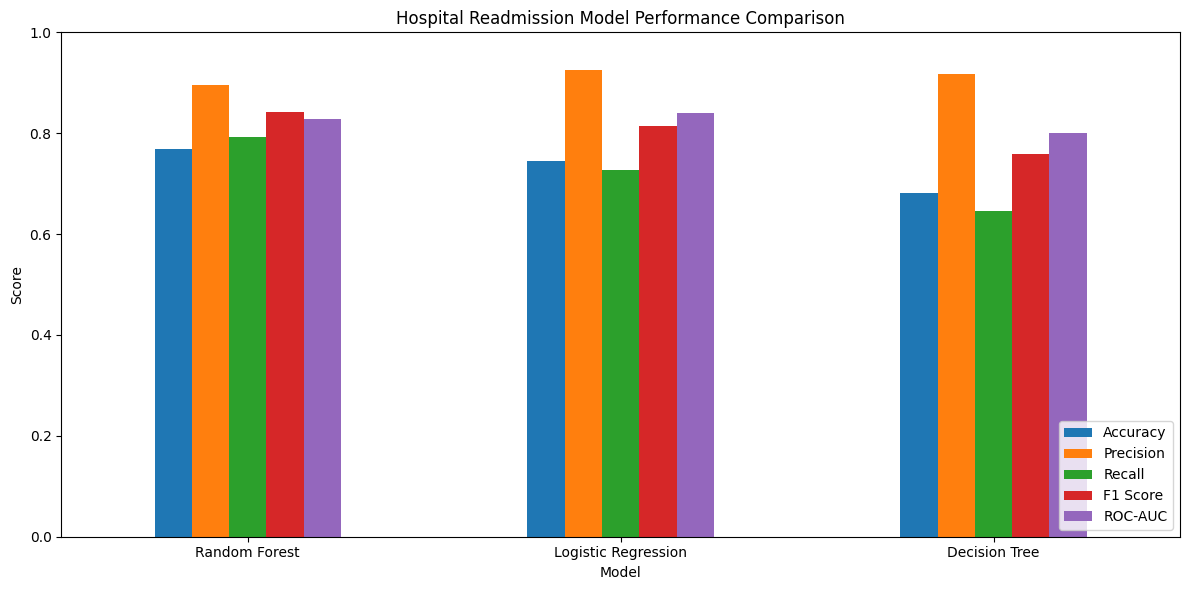

In [24]:
# ============================================================
# 11. VISUALIZE MODEL PERFORMANCE
# ============================================================

ax = results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Hospital Readmission Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()


### 12. SELECT BEST MODEL


In [25]:
# ============================================================
# 12. SELECT BEST MODEL
# ============================================================

# For this healthcare project, use F1-score
# as the initial selection criterion.

best_model_name = results_df.index[0]

best_model = trained_models[
    best_model_name
]

print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Selected Model:",
    best_model_name
)

print(
    "F1 Score:",
    round(
        results_df.loc[
            best_model_name,
            "F1 Score"
        ],
        4
    )
)




BEST MODEL
Selected Model: Random Forest
F1 Score: 0.8413


### 13. CONFUSION MATRIX FOR BEST MODEL


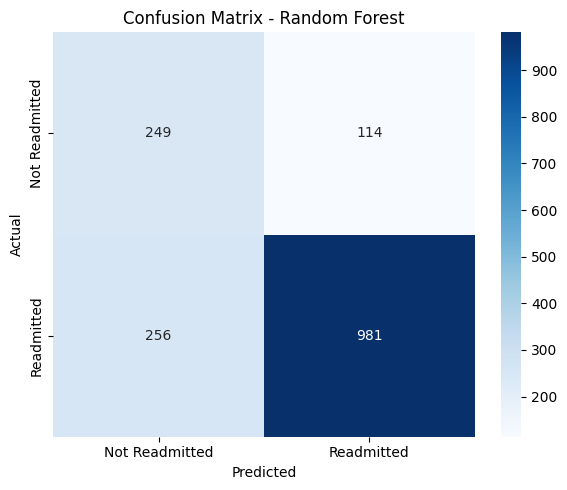

In [26]:
# ============================================================
# 13. CONFUSION MATRIX FOR BEST MODEL
# ============================================================

best_predictions = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Readmitted",
        "Readmitted"
    ],
    yticklabels=[
        "Not Readmitted",
        "Readmitted"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()


### 14. ROC CURVES FOR ALL MODELS


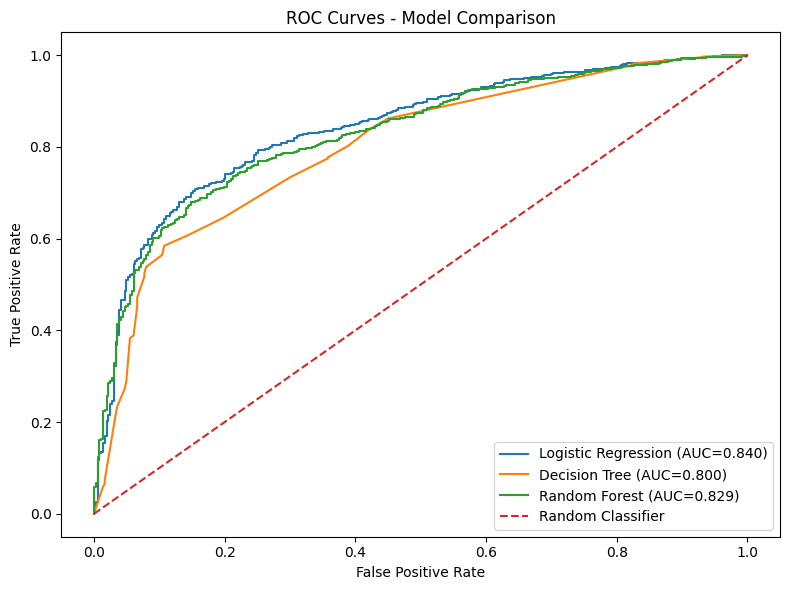

In [27]:
# ============================================================
# 14. ROC CURVES FOR ALL MODELS
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, pipeline in trained_models.items():

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - Model Comparison"
)

plt.legend()

plt.tight_layout()

plt.show()


### 15. SAVE BEST MODEL


In [28]:
# ============================================================
# 15. SAVE BEST MODEL
# ============================================================

save_model_path = "best_readmission_model.pkl" if not os.path.exists("/content") else "/content/best_readmission_model.pkl"

joblib.dump(
    best_model,
    save_model_path
)

# Also save into models/ folder if available
if os.path.exists("models") or os.path.exists("../models"):
    target_dir = "models" if os.path.exists("models") else "../models"
    joblib.dump(best_model, os.path.join(target_dir, "best_readmission_model.joblib"))

print(
    f"\nBest model saved successfully to: {save_model_path}"
)



Best model saved successfully to: /content/best_readmission_model.pkl


### 16. SAVE MODEL COMPARISON


In [29]:
# ============================================================
# 16. SAVE MODEL COMPARISON
# ============================================================

save_csv_path = "model_evaluation_results.csv" if not os.path.exists("/content") else "/content/model_evaluation_results.csv"

results_df.round(4).to_csv(
    save_csv_path
)

print(
    f"Model evaluation results saved successfully to: {save_csv_path}"
)


Model evaluation results saved successfully to: /content/model_evaluation_results.csv


### 17. FINAL EVALUATION SUMMARY


In [30]:
# ============================================================
# 17. FINAL EVALUATION SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MODEL EVALUATION COMPLETED")
print("=" * 70)

print(
    f"""
Best Model      : {best_model_name}

Accuracy        : {results_df.loc[best_model_name, 'Accuracy']:.4f}
Precision       : {results_df.loc[best_model_name, 'Precision']:.4f}
Recall          : {results_df.loc[best_model_name, 'Recall']:.4f}
F1 Score        : {results_df.loc[best_model_name, 'F1 Score']:.4f}
ROC-AUC         : {results_df.loc[best_model_name, 'ROC-AUC']:.4f}

The model was evaluated using an unseen test set.
"""
)

# ============================================================
# NEXT STEP
# ============================================================

print("""
Next steps:

06 - Hyperparameter Tuning
07 - Explainable AI / Feature Importance
08 - Final Model Saving
09 - Streamlit Application
10 - LLM Integration
11 - RAG Integration
""")




MODEL EVALUATION COMPLETED

Best Model      : Random Forest

Accuracy        : 0.7688
Precision       : 0.8959
Recall          : 0.7930
F1 Score        : 0.8413
ROC-AUC         : 0.8285

The model was evaluated using an unseen test set.


Next steps:

06 - Hyperparameter Tuning
07 - Explainable AI / Feature Importance
08 - Final Model Saving
09 - Streamlit Application
10 - LLM Integration
11 - RAG Integration

